In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

os.makedirs('output', exist_ok=True)
np.set_printoptions(precision=3, suppress=True)

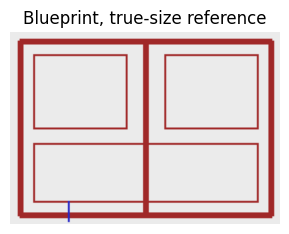

In [2]:
def make_blueprint(w=140, h=100):
    img = np.full((h, w, 3), (235, 235, 235), dtype=np.uint8)
    cv2.rectangle(img, (5, 5), (w - 5, h - 5), (40, 40, 160), 2)
    cv2.line(img, (w // 2, 5), (w // 2, h - 5), (40, 40, 160), 2)
    cv2.rectangle(img, (12, 12), (w // 2 - 10, h // 2), (40, 40, 160), 1)
    cv2.rectangle(img, (w // 2 + 10, 12), (w - 12, h // 2), (40, 40, 160), 1)
    cv2.rectangle(img, (12, h // 2 + 8), (w - 12, h - 12), (40, 40, 160), 1)
    cv2.line(img, (30, h - 12), (30, h - 2), (200, 40, 40), 1)
    return img

blueprint = make_blueprint()
cv2.imwrite('data_blueprint.png', blueprint)
plt.figure(figsize=(3.5, 2.5))
plt.imshow(cv2.cvtColor(blueprint, cv2.COLOR_BGR2RGB))
plt.title('Blueprint, true-size reference')
plt.axis('off')
plt.savefig('output/00_blueprint_reference.png', bbox_inches='tight', dpi=150)
plt.show()

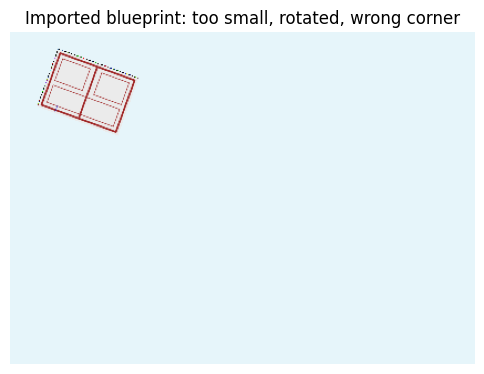

In [3]:
canvas_w, canvas_h = 420, 300
bh, bw = blueprint.shape[:2]
bp_center_local = np.array([bw / 2, bh / 2])

scale_wrong = 0.55
angle_wrong_deg = 20.0
corner_pos = np.array([70.0, 55.0])

theta_w = np.deg2rad(angle_wrong_deg)
R_w = np.array([[np.cos(theta_w), -np.sin(theta_w)],
                [np.sin(theta_w),  np.cos(theta_w)]])
S_w = np.eye(2) * scale_wrong
t_w = corner_pos - R_w @ S_w @ bp_center_local
M_wrong = np.hstack([R_w @ S_w, t_w.reshape(2, 1)])

def make_wall_bg(w, h):
    return np.full((h, w, 3), (250, 245, 230), dtype=np.uint8)

def composite(bg, layer, mask):
    out = bg.copy()
    out[mask > 0] = layer[mask > 0]
    return out

bp_mask_src = np.full((bh, bw), 255, dtype=np.uint8)
placed_bp = cv2.warpAffine(blueprint, M_wrong, (canvas_w, canvas_h), borderMode=cv2.BORDER_TRANSPARENT)
placed_mask = cv2.warpAffine(bp_mask_src, M_wrong, (canvas_w, canvas_h))

wall_bg = make_wall_bg(canvas_w, canvas_h)
scene = composite(wall_bg, placed_bp, placed_mask)

plt.figure(figsize=(6, 4.5))
plt.imshow(cv2.cvtColor(scene, cv2.COLOR_BGR2RGB))
plt.title('Imported blueprint: too small, rotated, wrong corner')
plt.axis('off')
plt.savefig('output/01_imported_wrong.png', bbox_inches='tight', dpi=150)
plt.show()

Scale correction matrix S =
 [[4.727 0.    0.   ]
 [0.    4.727 0.   ]
 [0.    0.    1.   ]]
Rotation correction matrix R =
 [[ 0.94   0.342  0.   ]
 [-0.342  0.94   0.   ]
 [ 0.     0.     1.   ]]
Combined 3x3 similarity matrix M = T @ R @ S @ T_to_origin =
 [[   4.442    1.617 -189.878]
 [  -1.617    4.442   18.857]
 [   0.       0.       1.   ]]


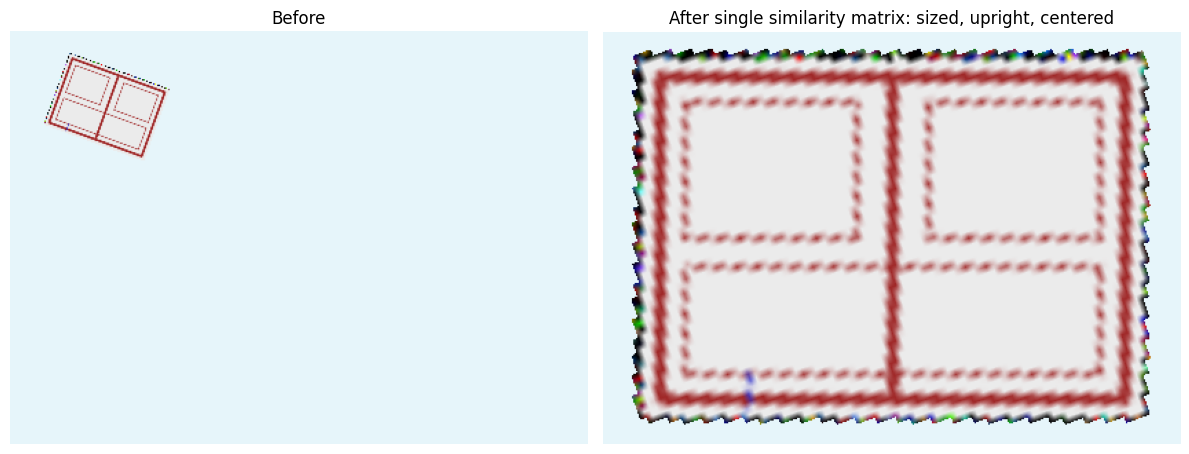

In [4]:
target_scale_total = 2.6
target_center = np.array([canvas_w / 2, canvas_h / 2])
scale_correction = target_scale_total / scale_wrong

S = np.array([
    [scale_correction, 0, 0],
    [0, scale_correction, 0],
    [0, 0, 1]
])
print('Scale correction matrix S =\n', S)

theta_fix = np.deg2rad(-angle_wrong_deg)
R = np.array([
    [np.cos(theta_fix), -np.sin(theta_fix), 0],
    [np.sin(theta_fix),  np.cos(theta_fix), 0],
    [0, 0, 1]
])
print('Rotation correction matrix R =\n', R)

T_to_origin = np.array([
    [1, 0, -corner_pos[0]],
    [0, 1, -corner_pos[1]],
    [0, 0, 1]
])
T_to_target = np.array([
    [1, 0, target_center[0]],
    [0, 1, target_center[1]],
    [0, 0, 1]
])

M = T_to_target @ R @ S @ T_to_origin
print('Combined 3x3 similarity matrix M = T @ R @ S @ T_to_origin =\n', M)

fixed_bp = cv2.warpAffine(placed_bp, M[:2, :], (canvas_w, canvas_h), borderMode=cv2.BORDER_TRANSPARENT)
fixed_mask = cv2.warpAffine(placed_mask, M[:2, :], (canvas_w, canvas_h))
fixed_scene = composite(wall_bg, fixed_bp, fixed_mask)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(scene, cv2.COLOR_BGR2RGB))
axes[0].set_title('Before')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(fixed_scene, cv2.COLOR_BGR2RGB))
axes[1].set_title('After single similarity matrix: sized, upright, centered')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('output/02_fixed.png', bbox_inches='tight', dpi=150)
plt.show()